# 01_EDA
- `data/diabetes.csv`를 이용해 EDA를 진행
- 특징 분포와 타깃(Outcome)의 패턴을 간단히 파악

## 1. 환경 설정과 데이터 로드
- 필요한 라이브러리를 불러오고 `df1`이라는 이름으로 원본 데이터를 메모리에 적재
- 이후 단계에서 모든 분석은 `df1`을 기준으로 수행

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

data_path = 'data/diabetes.csv'
df1 = pd.read_csv(data_path)
print(f'행/열 크기: {df1.shape}')
print(f'칼럼 이름 : {df1.columns}')

행/열 크기: (768, 9)
칼럼 이름 : Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


## 2. 데이터 구조 파악
데이터의 앞·뒤 행, 칼럼별 자료형을 확인해 값의 범위와 컬럼 구성을 빠르게 조망합니다.

> `.to_frame('쓸 함수명')` : Series 데이터 타입을 dataframe으로 변환하는 pandas 라이브러리 내 함수

In [2]:
display(df1.head())
display(df1.tail())
display(df1.dtypes.to_frame('data type'))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


,data type
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


- categorical data 도 (`Outcome`) 정수형으로 변환 되어 해당 데이터는 변환할 필요가 없을 

## 3. 기초 통계량
수치형 칼럼의 통계량과 사분위를 통해 전반적인 분포와 스케일을 파악하고, IQR(사분위 범위)로 이상치 가능성을 가늠합니다.

> `.T` (Transpose): 행과 열 바꿈

In [3]:
numeric_summary = df1.describe().T
numeric_summary['IQR'] = numeric_summary['75%'] - numeric_summary['25%']
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,IQR
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00,5.0000
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00,41.2500
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00,18.0000
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00,32.0000
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00,127.2500
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10,9.3000
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42,0.3825
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00,17.0000
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00,1.0000


## 4. 결측·이상 신호 점검
- 실제 결측치(`isna()`)수 확인
- 의학적으로 0이 나올 수 없는 변수들(예: Glucose, BMI 등)에서 0이 입력된 건수를 확인

In [4]:
missing = df1.isna().sum().to_frame('missing_count')
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
zero_counts = (df1[zero_cols] == 0).sum().to_frame('zero_count')
zero_counts['zero_ratio'] = (zero_counts['zero_count'] / len(df1)).round(3)
outlier_signals = missing.join(zero_counts, how='outer').fillna(0)
display(outlier_signals)
print(f"중복 행 수: {df1.duplicated().sum()} / {len(df1)}")

,missing_count,zero_count,zero_ratio
Age,0,0.0,0.000
BMI,0,11.0,0.014
BloodPressure,0,35.0,0.046
DiabetesPedigreeFunction,0,0.0,0.000
Glucose,0,5.0,0.007
Insulin,0,374.0,0.487
Outcome,0,0.0,0.000
Pregnancies,0,0.0,0.000
SkinThickness,0,227.0,0.296


중복 행 수: 0 / 768


## 5. 타깃 분포
당뇨병 여부(Outcome)의 비율을 확인해 데이터가 편향되어 있는지 판단합니다.

In [5]:
outcome_counts = df1['Outcome'].value_counts().to_frame('count')
outcome_counts['ratio'] = (outcome_counts['count'] / len(df1)).round(3)
display(outcome_counts)

,count,ratio
Outcome,,
0,500,0.651
1,268,0.349


- 정상인 대비 실제 당뇨병이 있는 사람이 다소 적은 것으로 확인됨 
 !!! 적다는 기준은?

## 6. 단변량 분포 시각화
모든 수치형 피처의 분포를 히스토그램과 KDE로 그려 분포 형태, 왜도, 이상값을 직관적으로 파악합니다.

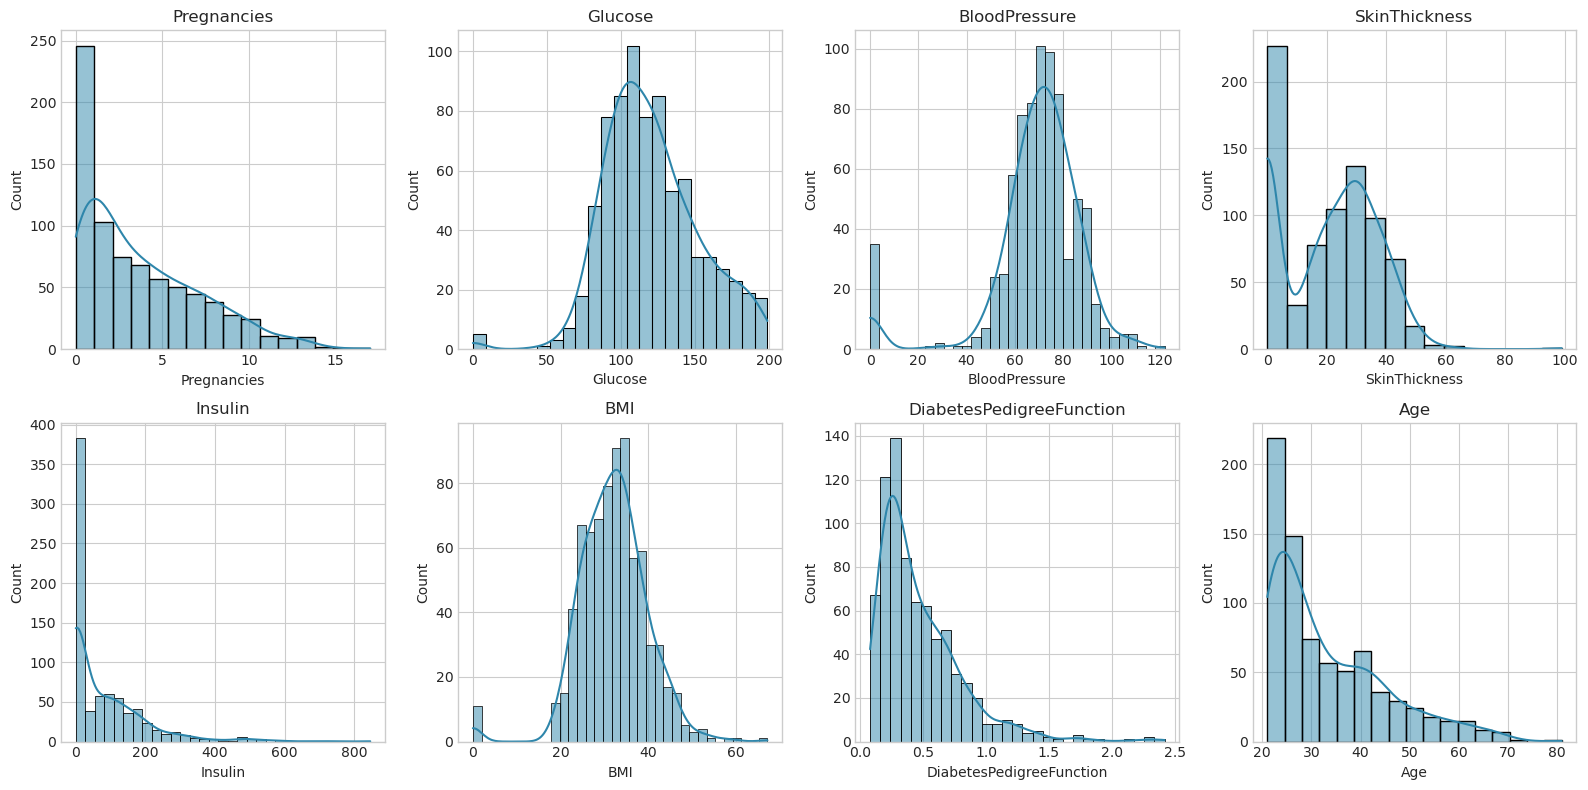

In [6]:
features = df1.columns.drop('Outcome')
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, features):
    sns.histplot(df1[col], kde=True, ax=ax, color='#2E86AB')
    ax.set_title(col)
for ax in axes[len(features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 7. 타깃별 분포 비교
중요한 생체 신호와 연령을 Outcome별로 박스플롯을 그려 그룹 간 차이가 있는지 시각적으로 비교합니다.

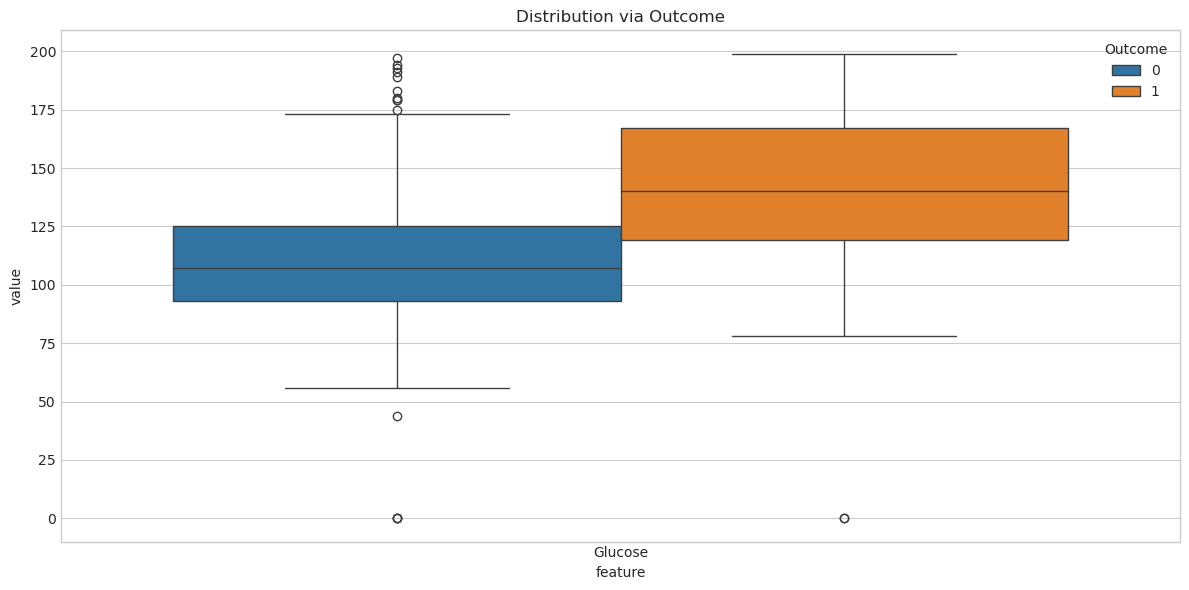

In [7]:
df_melt = df1.melt(id_vars='Outcome', value_vars='Glucose', var_name='feature', value_name='value')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt, x='feature', y='value', hue='Outcome')
plt.title('Distribution via Outcome')
plt.tight_layout()
plt.show()

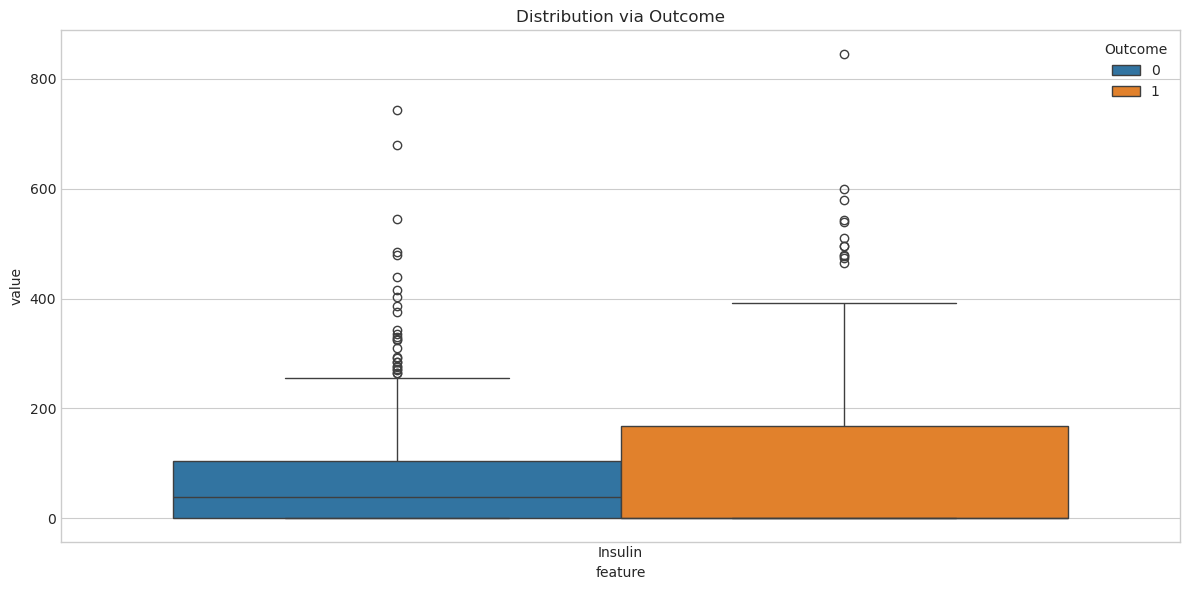

In [8]:
df_melt = df1.melt(id_vars='Outcome', value_vars='Insulin', var_name='feature', value_name='value')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt, x='feature', y='value', hue='Outcome')
plt.title('Distribution via Outcome')
plt.tight_layout()
plt.show()

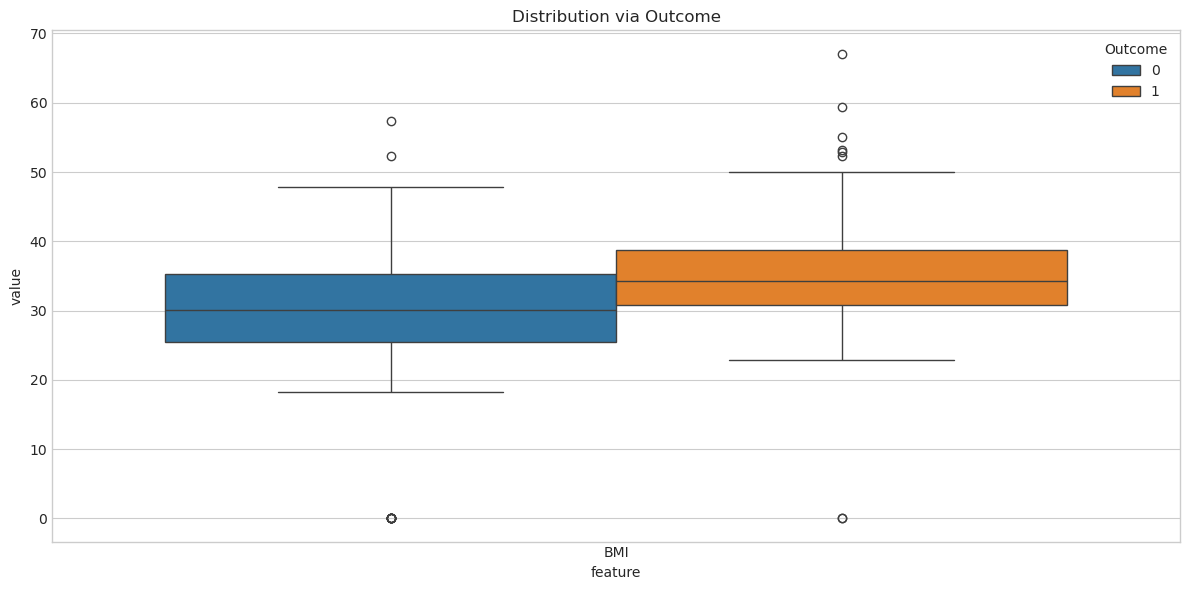

In [9]:
df_melt = df1.melt(id_vars='Outcome', value_vars='BMI', var_name='feature', value_name='value')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt, x='feature', y='value', hue='Outcome')
plt.title('Distribution via Outcome')
plt.tight_layout()
plt.show()

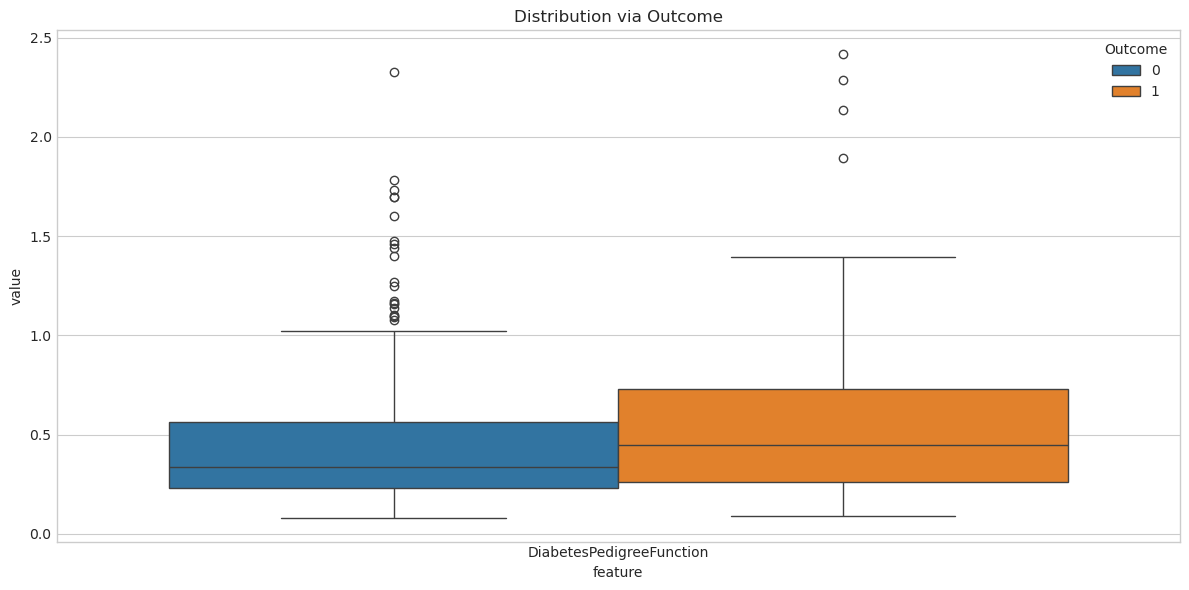

In [10]:
df_melt = df1.melt(id_vars='Outcome', value_vars='DiabetesPedigreeFunction', var_name='feature', value_name='value')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt, x='feature', y='value', hue='Outcome')
plt.title('Distribution via Outcome')
plt.tight_layout()
plt.show()

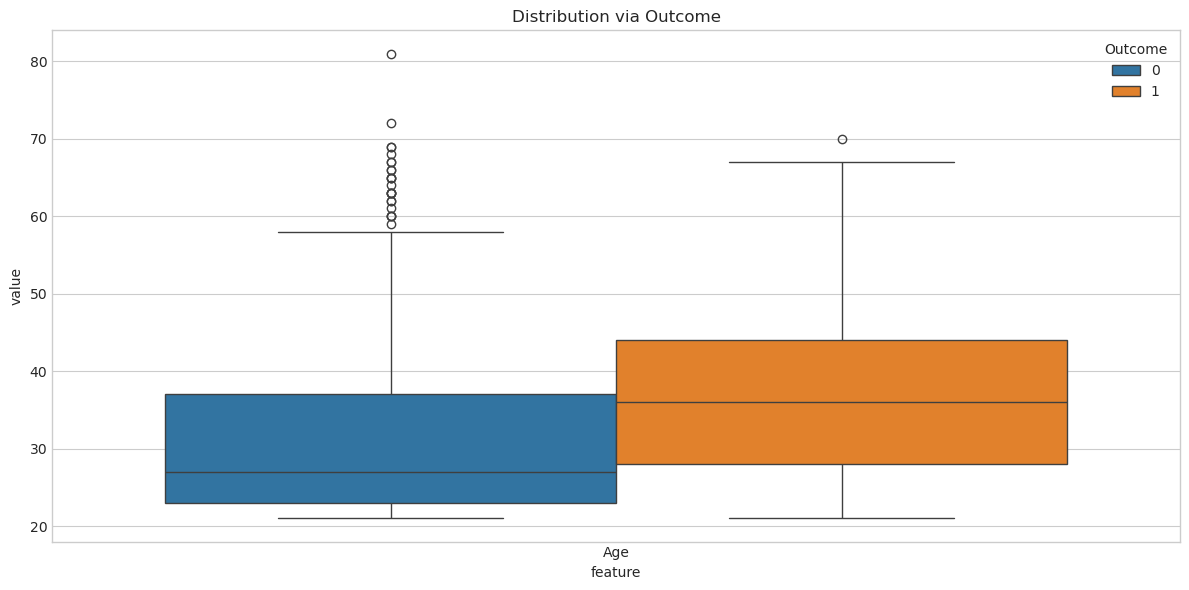

In [11]:
df_melt = df1.melt(id_vars='Outcome', value_vars='Age', var_name='feature', value_name='value')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt, x='feature', y='value', hue='Outcome')
plt.title('Distribution via Outcome')
plt.tight_layout()
plt.show()

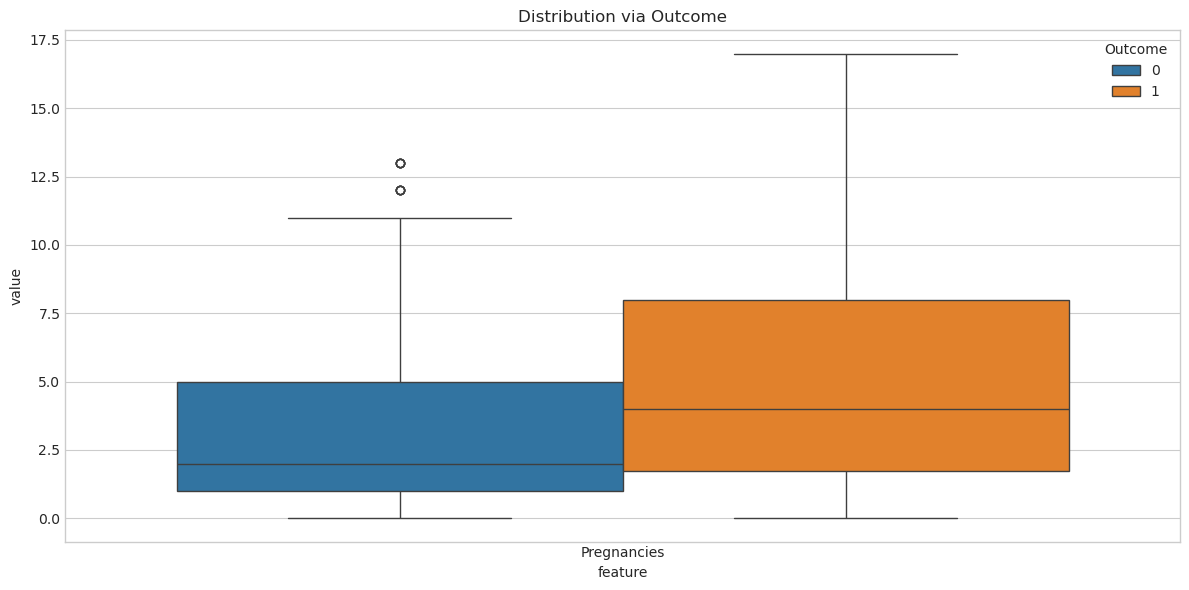

In [12]:
df_melt = df1.melt(id_vars='Outcome', value_vars='Pregnancies', var_name='feature', value_name='value')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt, x='feature', y='value', hue='Outcome')
plt.title('Distribution via Outcome')
plt.tight_layout()
plt.show()

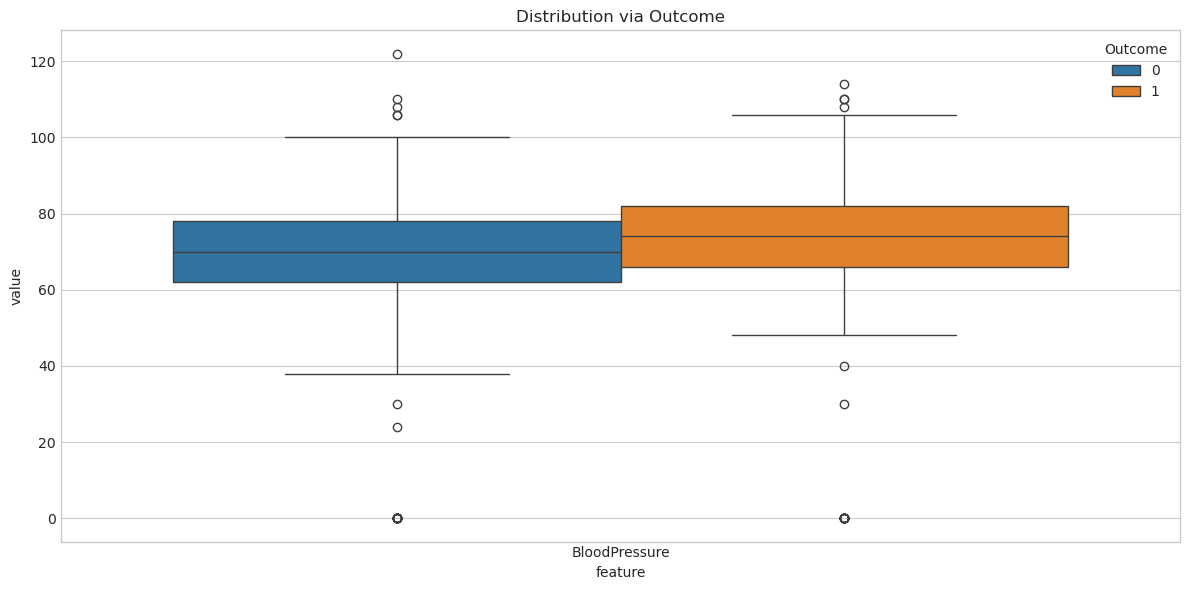

In [13]:
df_melt = df1.melt(id_vars='Outcome', value_vars='BloodPressure', var_name='feature', value_name='value')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt, x='feature', y='value', hue='Outcome')
plt.title('Distribution via Outcome')
plt.tight_layout()
plt.show()

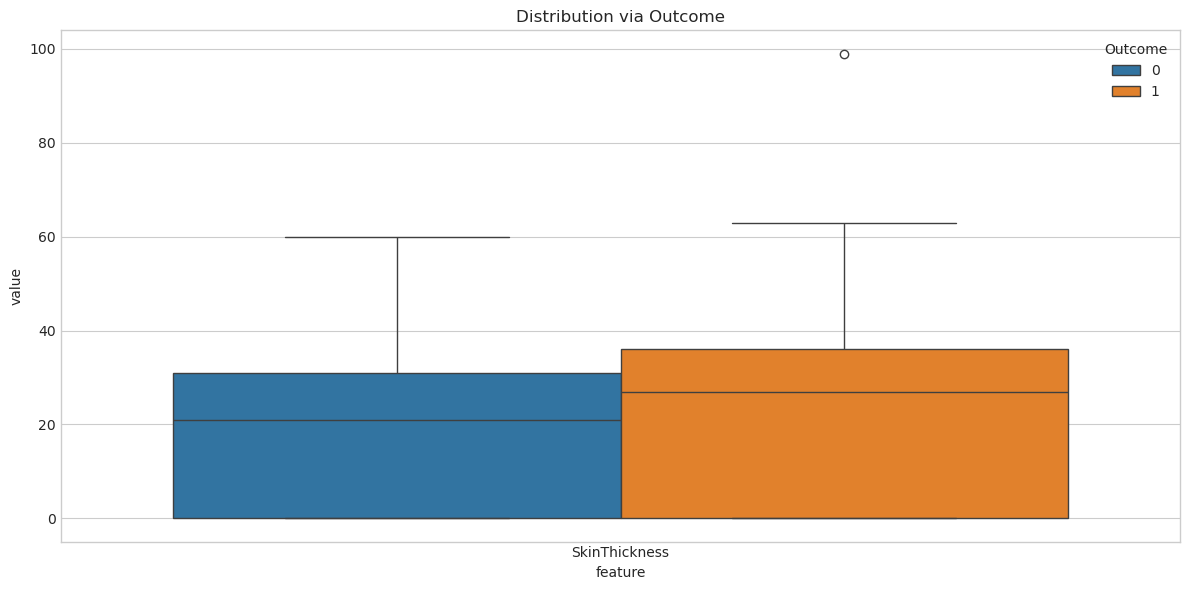

In [14]:
df_melt = df1.melt(id_vars='Outcome', value_vars='SkinThickness', var_name='feature', value_name='value')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt, x='feature', y='value', hue='Outcome')
plt.title('Distribution via Outcome')
plt.tight_layout()
plt.show()

## 8. 상관관계 분석
변수 간 선형 관계를 확인해 다중공선성 가능성과 강하게 연결된 변수 조합을 파악합니다.

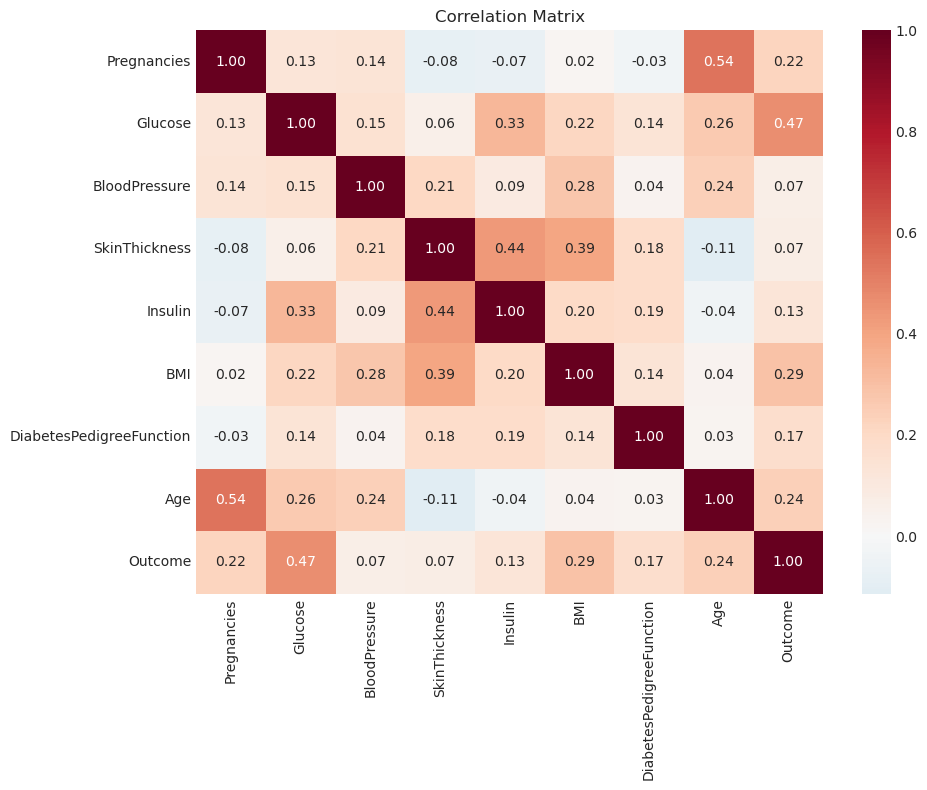

In [15]:
plt.figure(figsize=(10, 8))
corr = df1.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()